# 4.wav2vect · Modelización regresora sobre embeddings wav2vec2

Regresión sobre el **PHQ-8 continuo**, coherente con la línea principal del trabajo.

Se emplea **Random Forest regresor**, el mismo algoritmo de la línea principal y del nivel de
ventana, de modo que la comparación aísle el efecto de la representación y no el del algoritmo.
Los hiperparámetros se optimizan mediante **búsqueda aleatoria** sobre el mismo espacio y con el
mismo número de combinaciones que las otras dos líneas basadas en Random Forest.

Los embeddings se **promedian a nivel de sujeto** antes de modelizar, de modo que cada
participante constituye un único registro y las métricas resulten directamente comparables con
las del resto de enfoques.

## 0. Setup y datos

In [1]:
import numpy as np, pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, confusion_matrix,
                             precision_recall_fscore_support, mean_squared_error,
                             mean_absolute_error, r2_score, ConfusionMatrixDisplay)
from scipy.stats import randint
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
path_df = PROJECT_DIR + '/output/df_wav2vec_features.csv'
PHQ_THRESHOLD, RANDOM_STATE, N_CV = 10, 42, 5
N_ITER_SEARCH = 100     # mismas combinaciones que en la linea principal

df = pd.read_csv(path_df)
EMB = [c for c in df.columns if c.startswith('emb_')]

# pooling de los embeddings a nivel de sujeto
g = df.groupby('participant_id')
E = g[EMB].mean()
meta = g.agg(score=('phq8_score', 'first'), split=('split', 'first'))
y = meta['score'].astype(float)                      # <-- TARGET CONTINUO
ybin = (y >= PHQ_THRESHOLD).astype(int)

tr = meta['split'].isin(['train', 'dev']).values
te = (meta['split'] == 'test').values
Xtr, ytr = E[tr], y[tr]
Xte, yte = E[te], y[te]
yv = ybin[te].values

# particiones fijas, reutilizadas por la busqueda y por la evaluacion
cv_strat  = StratifiedKFold(N_CV, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv_strat.split(Xtr, ybin[tr]))

print(f"Sujetos: {len(E)} | train+dev {tr.sum()} sesiones ({ybin[tr].sum()} con sintomatologia)"
      f" | test {te.sum()} ({ybin[te].sum()})")
print(f"Embedding por sujeto: {E.shape[1]} dimensiones")
print(f"CV: {N_CV}-fold estratificada (stratify=phq8_binary), particiones fijas")

Sujetos: 186 | train+dev 140 sesiones (43 con sintomatologia) | test 46 (14)
Embedding por sujeto: 768 dimensiones
CV: 5-fold estratificada (stratify=phq8_binary), particiones fijas


## 1. Optimización de hiperparámetros

In [2]:
def build_pipe(**rf_kw):
    """Estandarizacion + Random Forest regresor."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('rf', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_kw)),
    ])


# Mismo espacio de busqueda y mismo numero de combinaciones que la linea principal
param_dist = {
    'rf__n_estimators':      randint(100, 600),
    'rf__max_depth':         [None, 5, 8, 10, 12, 15, 20],
    'rf__min_samples_split': randint(2, 30),
    'rf__min_samples_leaf':  randint(1, 15),
    'rf__max_features':      ['sqrt', 'log2', 0.3, 0.4, 0.5, 0.7],
}

search = RandomizedSearchCV(
    estimator=build_pipe(),
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    scoring='neg_root_mean_squared_error',
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(Xtr, ytr)

print('\nMejores hiperparametros:')
for k, v in search.best_params_.items():
    print(f'  {k.replace("rf__", ""):<20}: {v}')
print(f'\nMejor RMSE por sujeto (CV): {-search.best_score_:.3f}')

pipe = clone(search.best_estimator_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Mejores hiperparametros:
  max_depth           : 10
  max_features        : log2
  min_samples_leaf    : 6
  min_samples_split   : 23
  n_estimators        : 494

Mejor RMSE por sujeto (CV): 5.674


## 2. Validación cruzada y calibración del umbral

In [3]:
# Metricas de validacion cruzada y predicciones out-of-fold sobre train+dev
oof = np.zeros(len(Xtr))
rmse_f, mae_f, r2_f = [], [], []
for i, (i_tr, i_va) in enumerate(cv_splits, 1):
    m = clone(pipe).fit(Xtr.iloc[i_tr], ytr.iloc[i_tr])
    p_va = m.predict(Xtr.iloc[i_va])
    oof[i_va] = p_va
    rmse_f.append(np.sqrt(mean_squared_error(ytr.iloc[i_va], p_va)))
    mae_f.append(mean_absolute_error(ytr.iloc[i_va], p_va))
    r2_f.append(r2_score(ytr.iloc[i_va], p_va))
    print(f"  fold {i}/{N_CV}: RMSE {rmse_f[-1]:.3f}")

print(f"\n-- Evaluacion CV ({N_CV}-fold estratificada) --")
print(f"{'RMSE':<6} {np.mean(rmse_f):>7.3f}  +/- {np.std(rmse_f):.3f}")
print(f"{'MAE':<6} {np.mean(mae_f):>7.3f}  +/- {np.std(mae_f):.3f}")
print(f"{'R2':<6} {np.mean(r2_f):>7.3f}  +/- {np.std(r2_f):.3f}")

# umbral de decision que maximiza el F1 sobre las predicciones out-of-fold
ths = np.linspace(oof.min(), oof.max(), 200)
thr = ths[int(np.argmax([f1_score(ybin[tr], (oof >= t).astype(int), zero_division=0)
                         for t in ths]))]
print(f"\nUmbral optimo sobre OOF: {thr:.2f}")

  fold 1/5: RMSE 4.544
  fold 2/5: RMSE 4.392
  fold 3/5: RMSE 6.434
  fold 4/5: RMSE 6.332
  fold 5/5: RMSE 6.666

-- Evaluacion CV (5-fold estratificada) --
RMSE     5.674  +/- 0.991
MAE      4.752  +/- 0.941
R2      -0.023  +/- 0.039

Umbral optimo sobre OOF: 6.00


## 3. Evaluación en test

In [4]:
pipe.fit(Xtr, ytr)
p = pipe.predict(Xte)

# lineas base triviales, referencia para leer las metricas de clasificacion
_, _, f1_trivial, _ = precision_recall_fscore_support(
    yv, np.ones(len(yv)), average='binary', zero_division=0)

print('-- REGRESION (nivel sujeto, test) --')
print(f"  RMSE {np.sqrt(mean_squared_error(yte, p)):.3f} | "
      f"MAE {mean_absolute_error(yte, p):.3f} | R2 {r2_score(yte, p):.3f}")

print('\n-- CLASIFICACION DERIVADA --')
print(f"  AUC {roc_auc_score(yv, p):.3f}")
print(f"  Linea base trivial (marcar a todos):   F1  {f1_trivial:.3f}")
print(f"  Linea base trivial (clase mayoritaria): Acc {1 - yv.mean():.3f}")
for nom, t in [('nominal (>=10)', PHQ_THRESHOLD), (f'optimo OOF ({thr:.2f})', thr)]:
    yh = (p >= t).astype(int)
    pr, rc, f_, _ = precision_recall_fscore_support(yv, yh, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(yv, yh).ravel()
    print(f"  [{nom:<20}] Prec {pr:.3f} Rec {rc:.3f} F1 {f_:.3f} "
          f"Acc {accuracy_score(yv, yh):.3f}  TP {tp} FP {fp} FN {fn} TN {tn}")

print('\n  Referencia linea principal (RF nivel sesion): AUC 0.743 | F1 0.509')

-- REGRESION (nivel sujeto, test) --
  RMSE 6.310 | MAE 5.311 | R2 0.031

-- CLASIFICACION DERIVADA --
  AUC 0.585
  Linea base trivial (marcar a todos):   F1  0.467
  Linea base trivial (clase mayoritaria): Acc 0.696
  [nominal (>=10)      ] Prec 0.000 Rec 0.000 F1 0.000 Acc 0.696  TP 0 FP 0 FN 14 TN 32
  [optimo OOF (6.00)   ] Prec 0.308 Rec 0.857 F1 0.453 Acc 0.370  TP 12 FP 27 FN 2 TN 5

  Referencia linea principal (RF nivel sesion): AUC 0.743 | F1 0.509


## 4. Matriz de confusión

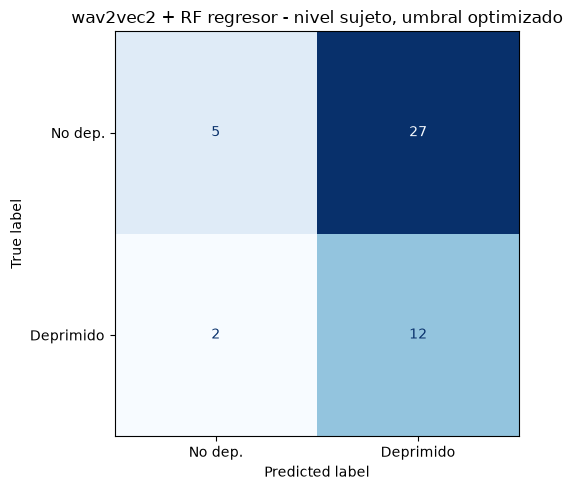

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    yv, (p >= thr).astype(int),
    display_labels=['No dep.', 'Deprimido'], colorbar=False, ax=ax, cmap='Blues')
ax.set_title('wav2vec2 + RF regresor - nivel sujeto, umbral optimizado')
plt.tight_layout(); plt.show()